# What is actually in here

A tour of the corpus through examples, meant to be run and looked at rather than read.

956 million series from FRED, Eurostat and OECD. That number is not the interesting part — most
of it is thin cross-products, as the quality report will tell you at length. The interesting part
is that the corpus reaches down to *individual products, species and regions*, monthly, for
thirty years, and that you can find any of it in about a second.

Every example below was found with `terrastat search`, and every number is pulled live from the
series layer, so re-running this after a crawl shows whatever is there now.

In [1]:
import datetime as dt
import matplotlib.pyplot as plt
import polars as pl

from terrastat import search
from terrastat.quality import scan

plt.rcParams.update({"figure.figsize": (9, 3.4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

COLS = ["dataset_id", "description", "frequency", "n_obs", "dates", "values"]

def series(dataset_id, *must, n=1, min_obs=10):
    """The first n series of a dataset whose description matches every pattern in `must`."""
    q = scan(columns=COLS).filter(pl.col("dataset_id") == dataset_id)
    for m in must:
        q = q.filter(pl.col("description").str.contains("(?i)" + m))
    return q.filter(pl.col("n_obs") >= min_obs).head(n).collect()

def plot(rows, title, ylabel="", labeller=None, ax=None):
    ax = ax or plt.subplots()[1]
    for r in rows.iter_rows(named=True):
        lab = labeller(r) if labeller else r["description"][:40]
        ax.plot(r["dates"], r["values"], lw=1.4, label=lab)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel(ylabel)
    if rows.height > 1:
        ax.legend(fontsize=7, frameon=False)
    return ax

## Finding things

`search` looks at each dataset's title, description, dimension names **and every code label
inside it**. That last part is what makes it work: nothing in this corpus has a title containing
"olive oil", but a Eurostat price dataset has it as one of 468 COICOP codes.

In [2]:
search.search("olive oil|honey", min_series=1000).head(5).select(
    "source", "dataset_id", "title", "n_series", "where", "matched_labels")

source,dataset_id,title,n_series,where,matched_labels
str,str,str,i64,str,str
"""eurostat""","""fish_ld_main""","""Landings of fishery products -…",413515,"""labels""","""Himantura uarnak (Honeycomb st…"
"""eurostat""","""aact_eaa01_r""","""Economic accounts for agricult…",277842,"""labels""","""Olive oil"""
"""eurostat""","""env_landfp_imp""","""Land use embodied in imports i…",199451,"""labels""","""Olive oil and its fractions, w…"
"""eurostat""","""aact_eaa05""","""Economic accounts for agricult…",171236,"""labels""","""Olive oil"""
"""eurostat""","""agr_r_accts_h""","""Economic accounts for agricult…",159858,"""labels""","""Olive oil"""


## 1. The price of one thing, monthly, for thirty years

`prc_hicp_midx` is the Harmonised Index of Consumer Prices: **468 products x 45 countries,
monthly since 1996**. Not "food" — *olive oil*, *lager beer*, *chocolate*, *carpets*,
*hairdressing for men*.

Greek olive oil roughly **doubles in 2023**. That is the Mediterranean drought, in monthly
resolution, in a dataset most people would describe as "European inflation statistics".

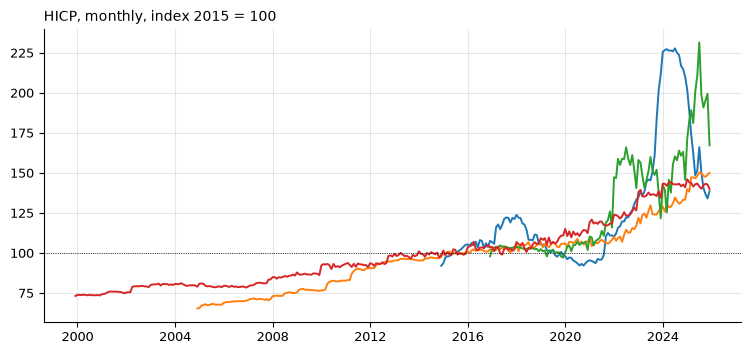

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for item, country in [("Olive oil", "Greece"), ("Chocolate", "Belgium"),
                      ("Coffee", "Finland"), ("Beer", "Czechia")]:
    r = series("prc_hicp_midx", f": {item}\\.", country, "2015=100|2015 = 100", min_obs=100)
    if r.height:
        plot(r, "", labeller=lambda _: f"{item}, {country}", ax=ax)
ax.set_title("HICP, monthly, index 2015 = 100", loc="left", fontsize=10)
ax.axhline(100, color="k", lw=.6, ls=":")
plt.show()

## 2. Fish, by species

`OECD.TAD.ARP__DSD_FISH_PROD_DF_FISH_INLAND__1.0` — inland fisheries production, **363 species
across 53 countries**, annual since 1995, in tonnes. The species dimension is real fisheries
taxonomy: *Tilapias nei [Oreochromis spp]*, where "nei" is FAO's "not elsewhere included".

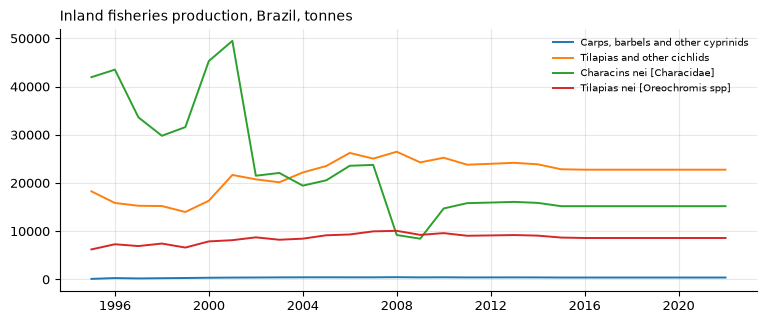

In [4]:
r = series("OECD.TAD.ARP__DSD_FISH_PROD_DF_FISH_INLAND__1.0", "Brazil", "Tilapias|Carps|Characins", n=4)
plot(r, "Inland fisheries production, Brazil, tonnes",
     labeller=lambda x: x["description"].split("Species: ")[1].split(".")[0][:34])
plt.show()

## 3. The internet arriving

`isoc_ci_in_h` — households with internet access, annual since 2002. A textbook adoption curve
that you can put a country's name on.

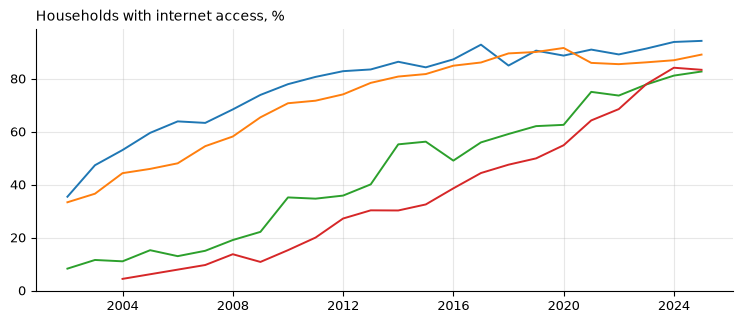

In [5]:
fig, ax = plt.subplots()
for geo in ["Denmark", "Germany", "Greece", "Bulgaria"]:
    r = series("isoc_ci_in_h", "Percentage of households", f"area: {geo}\\.|: {geo}\\.", min_obs=12)
    if r.height:
        plot(r, "", labeller=lambda _: geo, ax=ax)
ax.set_title("Households with internet access, % ", loc="left", fontsize=10)
plt.show()

## 4. The COVID cliff

`tour_occ_nim` — nights spent in tourist accommodation, **monthly since 1990**. Around 210
observations per series, which is enough to see seasonality and one very abrupt structural break
in the same picture.

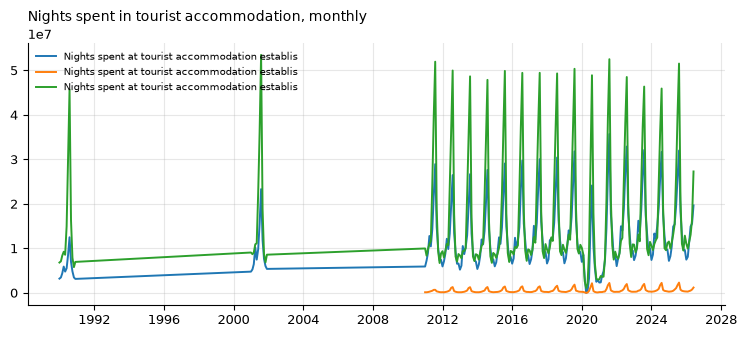

In [6]:
r = series("tour_occ_nim", "Spain|Italy|Croatia", n=3, min_obs=150)
plot(r, "Nights spent in tourist accommodation, monthly",
     labeller=lambda x: x["description"][:46])
plt.show()

## 5. Three quarters of a century of house prices

`OECD.SDD.TPS__DSD_RHPI_DF_RHPI_ALL__1.0` — national and regional house price indices, some
running **from 1947**, about 97 observations per series. One of the longest well-maintained
families in the corpus.

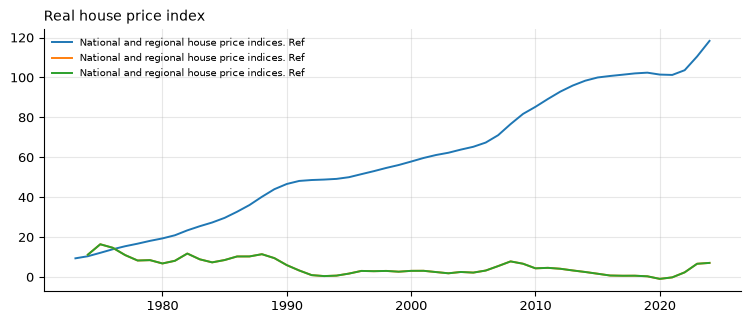

In [7]:
r = series("OECD.SDD.TPS__DSD_RHPI_DF_RHPI_ALL__1.0", "Australia|United States|Japan", n=3, min_obs=45)
plot(r, "Real house price index", labeller=lambda x: x["description"][:46])
plt.show()

## 6. Fifty years of rubbish, and other odd corners

- `OECD.ENV.EPI__DSD_MUNW_DF_MUNW__1.0` — municipal waste, **1975-2024**, 68 countries
- `OECD.STI.PIE__DSD_PATENTS...` — patent applications, **1976-2024**
- `sprt_trd_prd` — intra- and extra-EU trade in **sporting goods by product**, down to tennis
  balls, since 2004
- `ef_lsk_bees` — beehives on farms by NUTS-2 region
- `orch_olives1` — olive trees by **age class**, including "50 years or over"

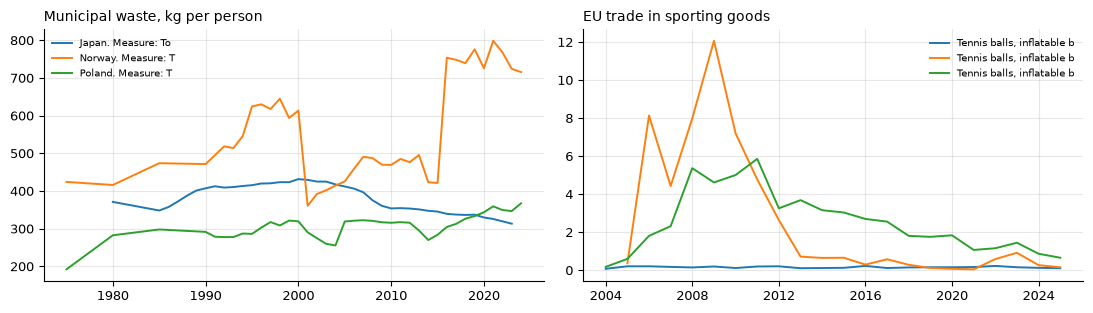

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
r = series("OECD.ENV.EPI__DSD_MUNW_DF_MUNW__1.0", "Kilogrammes per person", "Japan|Norway|Poland", n=3, min_obs=25)
plot(r, "Municipal waste, kg per person", labeller=lambda x: x["description"].split("area: ")[1][:18], ax=axes[0])
r = series("sprt_trd_prd", "ball|Ski|bicycle", n=3, min_obs=15)
plot(r, "EU trade in sporting goods", labeller=lambda x: x["description"].split("products: ")[-1][:26], ax=axes[1])
plt.tight_layout(); plt.show()

## 7. A cautionary example

`vit_bs4_it` is the most charming metadata in the corpus: Italian vineyard area by **370
grape varieties** (Aglianico, Abbuoto, Aglianicone...) crossed with **nine vine age classes** and
104 provinces. 221,418 series.

It holds 270,624 observations. That is **1.2 per series**. It is a survey, not a time series.

This is the single most important thing to understand about the corpus, and the reason the
quality report puts the median observation count next to every series count.

In [9]:
import json, pathlib
m = json.loads(pathlib.Path("../data/datasets/eurostat/vit_bs4_it/dataset.json").read_text(encoding="utf-8"))
print(f"{m['title'][:78]}")
print(f"  {m['n_series']:,} series but only {m['n_obs']:,} observations "
      f"-- {m['n_obs']/m['n_series']:.2f} per series")
for d in m["dimensions"]:
    print(f"  {d['id']:10} {len(d.get('codes') or {}):>4} codes  {d['name'][:44]}")

Area under wine-grape vine varieties broken down by vine variety and by age of
  221,418 series but only 270,624 observations -- 1.22 per series
  freq          1 codes  Time frequency
  indic_vi      1 codes  Survey on variables under vines
  wine_var    370 codes  Wine-grape vine variety
  age           9 codes  Age class
  geo         104 codes  Geopolitical entity (reporting)


## From a search to a training set

The two halves compose: `search` says what a dataset is about, `selection` says whether its series
are worth modelling.

In [10]:
from terrastat import selection

hits = search.search("tourism|nights spent", min_series=500)
uids = search.series_of(hits.get_column("dataset_id").to_list()[:5]).select("series_uid").collect()
print(f"{hits.height} tourism datasets, {uids.height:,} series")
print("\nthen: terrastat select --sources eurostat   (scores them)")
print("      selection.load_scores() -> join on series_uid -> rank on recency, length, information")

124 tourism datasets, 9,704 series

then: terrastat select --sources eurostat   (scores them)
      selection.load_scores() -> join on series_uid -> rank on recency, length, information
